In [72]:
# ==============================================================================
# PIPELINE: MÔ HÌNH LENET-5 (PHIÊN BẢN FILTER 5x5 TOÀN PHẦN)
# OPTIMIZER: ADAM
# ==============================================================================
#
# 1. CẤU TRÚC MẠNG (ARCHITECTURE):
# ------------------------------------------------------------------------------
#   INPUT  : Ảnh MNIST (28 x 28 x 1)
#     |
#   CONV 1 : 8 Filters (5x5), Padding=2  --> Tầm nhìn rộng ngay từ lớp đầu
#   ReLU 1 : Kích hoạt phi tuyến
#   POOL 1 : Max Pooling (2x2)           --> Output: (8, 14, 14)
#     |
#   CONV 2 : 16 Filters (5x5), Padding=2 --> Trích xuất đặc trưng hình thể lớn
#   ReLU 2 : Kích hoạt phi tuyến
#   POOL 2 : Max Pooling (2x2)           --> Output: (16, 7, 7)
#     |
#   FLATTEN: Vector hóa (16 * 7 * 7) = 784 nodes
#     |
#   FC 1   : Dense Layer (64 nodes) + ReLU
#   FC 2   : Output Layer (10 nodes) + Softmax
#
# 2. ĐẶC ĐIỂM CỦA FILTER 5x5:
# ------------------------------------------------------------------------------
#   - Ưu điểm: Nắm bắt các cấu trúc hình học phức tạp nhanh hơn filter 3x3.
#   - Chi phí: Tính toán nặng hơn (25 phép nhân/vùng thay vì 9).
#   - Phù hợp: Rất tốt cho các bài toán nhận diện chữ số có nhiều đường cong.
# ==============================================================================

# 1 Khởi tạo và Tiền xử lý dữ liệu

In [73]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time

# 1. Tải dữ liệu MNIST từ thư viện
print("Đang tải dữ liệu MNIST...")
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# 2. Tiền xử lý dữ liệu
# Chuẩn hóa về khoảng [-0.5, 0.5] giúp mạng hội tụ nhanh và ổn định hơn
train_size = 1000 # Lấy mẫu nhỏ để demo chạy nhanh trên CPU
test_size = 200

x_train = x_train_raw[:train_size] / 255.0 - 0.5
y_train = y_train_raw[:train_size]
x_test = x_test_raw[:test_size] / 255.0 - 0.5
y_test = y_test_raw[:test_size]

print(f"Dữ liệu huấn luyện: {x_train.shape}")
print(f"Dữ liệu kiểm tra: {x_test.shape}")

Đang tải dữ liệu MNIST...
Dữ liệu huấn luyện: (1000, 28, 28)
Dữ liệu kiểm tra: (200, 28, 28)


# 2: Các lớp nền tảng (Backprop thủ công)

In [74]:
import numpy as np

class ConvLayer:
    def __init__(self, in_channels, num_filters, filter_size, padding=1):
        self.in_channels = in_channels
        self.num_filters = num_filters
        self.f = filter_size
        self.padding = padding
        # Khởi tạo Xavier
        limit = np.sqrt(6 / (in_channels * filter_size**2 + num_filters))
        self.filters = np.random.uniform(-limit, limit, (num_filters, in_channels, filter_size, filter_size))
        self.bias = np.zeros((num_filters, 1))

        # Các biến trạng thái cho Adam
        self.m_f, self.v_f = np.zeros_like(self.filters), np.zeros_like(self.filters)
        self.m_b, self.v_b = np.zeros_like(self.bias), np.zeros_like(self.bias)
        self.beta1, self.beta2 = 0.9, 0.999
        self.epsilon = 1e-8
        self.t = 0 # Bộ đếm bước thời gian

    def add_padding(self, image):
        if self.padding == 0: return image
        return np.pad(image, ((0,0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')

    def forward(self, input_data):
        if len(input_data.shape) == 2: input_data = input_data[np.newaxis, :, :]
        self.last_input = input_data
        padded_input = self.add_padding(input_data)
        out_h = input_data.shape[1] + 2 * self.padding - self.f + 1
        out_w = input_data.shape[2] + 2 * self.padding - self.f + 1
        output = np.zeros((self.num_filters, out_h, out_w))

        for n in range(self.num_filters):
            for i in range(out_h):
                for j in range(out_w):
                    im_region = padded_input[:, i:i+self.f, j:j+self.f]
                    output[n, i, j] = np.sum(im_region * self.filters[n]) + float(self.bias[n, 0])
        return output

    def backward(self, d_out, lr):
        self.t += 1
        d_filters = np.zeros_like(self.filters)
        padded_input = self.add_padding(self.last_input)
        d_padded_input = np.zeros_like(padded_input)

        for n in range(self.num_filters):
            for i in range(d_out.shape[1]):
                for j in range(d_out.shape[2]):
                    d_filters[n] += d_out[n, i, j] * padded_input[:, i:i+self.f, j:j+self.f]
                    d_padded_input[:, i:i+self.f, j:j+self.f] += d_out[n, i, j] * self.filters[n]

        d_input = d_padded_input[:, self.padding:-self.padding, self.padding:-self.padding] if self.padding > 0 else d_padded_input

        # Thuật toán ADAM cho Filters
        self.m_f = self.beta1 * self.m_f + (1 - self.beta1) * d_filters
        self.v_f = self.beta2 * self.v_f + (1 - self.beta2) * (d_filters**2)
        m_hat = self.m_f / (1 - self.beta1**self.t)
        v_hat = self.v_f / (1 - self.beta2**self.t)
        self.filters -= lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

        # Thuật toán ADAM cho Bias
        d_bias = np.sum(d_out, axis=(1, 2)).reshape(self.num_filters, 1)
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * d_bias
        self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (d_bias**2)
        m_hat_b = self.m_b / (1 - self.beta1**self.t)
        v_hat_b = self.v_b / (1 - self.beta2**self.t)
        self.bias -= lr * m_hat_b / (np.sqrt(v_hat_b) + self.epsilon)

        return d_input

class MaxPoolLayer:
    def __init__(self, size=2):
        self.size = size
    def forward(self, input_data):
        self.last_input = input_data
        c, h, w = input_data.shape
        output = np.zeros((c, h // self.size, w // self.size))
        for i in range(h // self.size):
            for j in range(w // self.size):
                im_region = input_data[:, i*self.size:(i+1)*self.size, j*self.size:(j+1)*self.size]
                output[:, i, j] = np.max(im_region, axis=(1, 2))
        return output
    def backward(self, d_out):
        d_input = np.zeros(self.last_input.shape)
        c, h, w = self.last_input.shape
        for i in range(h // self.size):
            for j in range(w // self.size):
                im_region = self.last_input[:, i*self.size:(i+1)*self.size, j*self.size:(j+1)*self.size]
                for n in range(c):
                    idx = np.argmax(im_region[n])
                    coords = np.unravel_index(idx, (self.size, self.size))
                    d_input[n, i*self.size + coords[0], j*self.size + coords[1]] = d_out[n, i, j]
        return d_input

class ReLULayer:
    def forward(self, input_data):
        self.last_input = input_data
        return np.maximum(0, input_data)
    def backward(self, d_out):
        d_input = d_out.copy()
        d_input[self.last_input <= 0] = 0
        return d_input

class FCLayer:
    def __init__(self, input_len, nodes):
        limit = np.sqrt(6 / (input_len + nodes))
        self.weights = np.random.uniform(-limit, limit, (input_len, nodes))
        self.biases = np.zeros(nodes)

        # Các biến trạng thái Adam cho FC
        self.m_w, self.v_w = np.zeros_like(self.weights), np.zeros_like(self.weights)
        self.m_b, self.v_b = np.zeros_like(self.biases), np.zeros_like(self.biases)
        self.beta1, self.beta2 = 0.9, 0.999
        self.epsilon = 1e-8
        self.t = 0

    def forward(self, input_data):
        self.last_input_shape = input_data.shape
        self.last_input = input_data.flatten()
        return np.dot(self.last_input, self.weights) + self.biases

    def backward(self, d_out, lr):
        self.t += 1
        d_weights = np.dot(self.last_input.reshape(-1, 1), d_out.reshape(1, -1))
        d_input = np.dot(d_out, self.weights.T)

        # ADAM cho Weights
        self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * d_weights
        self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (d_weights**2)
        m_hat_w = self.m_w / (1 - self.beta1**self.t)
        v_hat_w = self.v_w / (1 - self.beta2**self.t)
        self.weights -= lr * m_hat_w / (np.sqrt(v_hat_w) + self.epsilon)

        # ADAM cho Biases
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * d_out
        self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (d_out**2)
        m_hat_b = self.m_b / (1 - self.beta1**self.t)
        v_hat_b = self.v_b / (1 - self.beta2**self.t)
        self.biases -= lr * m_hat_b / (np.sqrt(v_hat_b) + self.epsilon)

        return d_input.reshape(self.last_input_shape)

# 3: Kiến trúc Mô hình (CNN Architecture)

In [75]:
class HandcraftedCNN:
    def __init__(self):
        # Layer 1: Chuyển sang 5x5, dùng Padding=2 để giữ nguyên 28x28 trước khi Pool
        self.conv1 = ConvLayer(in_channels=1, num_filters=8, filter_size=5, padding=2)
        self.relu1 = ReLULayer()
        self.pool1 = MaxPoolLayer(size=2) # Kết quả: 14x14

        # Layer 2: Chuyển sang 5x5, dùng Padding=2 để giữ nguyên 14x14 trước khi Pool
        self.conv2 = ConvLayer(in_channels=8, num_filters=16, filter_size=5, padding=2)
        self.relu2 = ReLULayer()
        self.pool2 = MaxPoolLayer(size=2) # Kết quả: 7x7

        # Fully Connected: Giữ nguyên số lượng node vì kích thước cuối vẫn là 7x7
        self.fc1 = FCLayer(input_len=16 * 7 * 7, nodes=64)
        self.relu_fc1 = ReLULayer()
        self.fc2 = FCLayer(input_len=64, nodes=10)

    def forward(self, image):
        # Quy trình lan truyền tiến qua các lớp 5x5
        x = self.pool1.forward(self.relu1.forward(self.conv1.forward(image)))
        x = self.pool2.forward(self.relu2.forward(self.conv2.forward(x)))
        x = self.relu_fc1.forward(self.fc1.forward(x))
        out = self.fc2.forward(x)

        # Softmax ổn định số học
        out_s = out - np.max(out)
        exp = np.exp(out_s)
        return exp / (np.sum(exp) + 1e-15)

    def train(self, image, label, lr):
        # 1. Forward
        probs = self.forward(image)

        # 2. Loss gradient
        loss_grad = probs.copy()
        loss_grad[label] -= 1

        # 3. Backward (Các lớp tự xử lý đạo hàm theo filter 5x5)
        grad = self.fc2.backward(loss_grad, lr)
        grad = self.fc1.backward(self.relu_fc1.backward(grad), lr)
        grad = self.conv2.backward(self.relu2.backward(self.pool2.backward(grad)), lr)
        grad = self.conv1.backward(self.relu1.backward(self.pool1.backward(grad)), lr)

        return -np.log(probs[label] + 1e-15)

# 4: Huấn luyện và Demo thực tế

In [76]:
model = HandcraftedCNN()
lr = 0.001
epochs = 2
all_losses = []

print("--- HUẤN LUYỆN CNN VỚI BỘ TỐI ƯU HÓA ADAM ---")
start_time = time.time()

for epoch in range(epochs):
    for i, (img, lbl) in enumerate(zip(x_train, y_train)):
        l = model.train(img, lbl, lr)
        all_losses.append(l)

        if (i + 1) % 100 == 0:
            print(f"Epoch {epoch+1} | {i+1}/1000 | Loss: {l:.4f}")

print(f"Hoàn thành huấn luyện trong: {(time.time() - start_time)/60:.2f} phút")

--- HUẤN LUYỆN CNN VỚI BỘ TỐI ƯU HÓA ADAM ---
Epoch 1 | 100/1000 | Loss: 1.7519
Epoch 1 | 200/1000 | Loss: 0.6225
Epoch 1 | 300/1000 | Loss: 0.1468
Epoch 1 | 400/1000 | Loss: 2.4659
Epoch 1 | 500/1000 | Loss: 0.2440
Epoch 1 | 600/1000 | Loss: 0.2645
Epoch 1 | 700/1000 | Loss: 0.3365
Epoch 1 | 800/1000 | Loss: 0.0081
Epoch 1 | 900/1000 | Loss: 0.8791
Epoch 1 | 1000/1000 | Loss: 0.0366
Epoch 2 | 100/1000 | Loss: 0.0096
Epoch 2 | 200/1000 | Loss: 0.0026
Epoch 2 | 300/1000 | Loss: 0.0128
Epoch 2 | 400/1000 | Loss: 0.0136
Epoch 2 | 500/1000 | Loss: 0.0087
Epoch 2 | 600/1000 | Loss: 0.0056
Epoch 2 | 700/1000 | Loss: 0.1357
Epoch 2 | 800/1000 | Loss: 0.0009
Epoch 2 | 900/1000 | Loss: 0.0239
Epoch 2 | 1000/1000 | Loss: 0.0207
Hoàn thành huấn luyện trong: 7.18 phút


# 5: Vẽ biểu đồ Loss

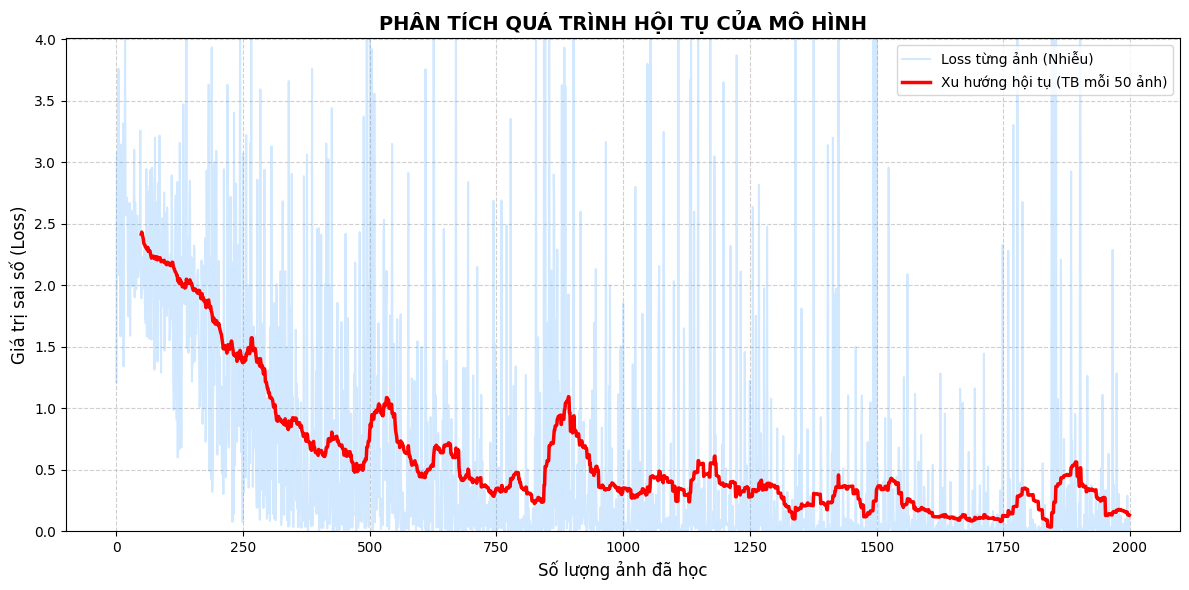

In [77]:
def plot_results(losses, window=50):
    plt.figure(figsize=(12, 6))

    # 1. Vẽ dữ liệu gốc (mờ đi để làm nền)
    plt.plot(losses, color='dodgerblue', alpha=0.2, label='Loss từng ảnh (Nhiễu)')

    # 2. Tính toán đường trung bình trượt để làm mượt
    if len(losses) > window:
        smooth_losses = np.convolve(losses, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(losses)), smooth_losses, color='red', linewidth=2.5, label=f'Xu hướng hội tụ (TB mỗi {window} ảnh)')

    # Tinh chỉnh hiển thị
    plt.ylim(0, max(losses[:100]) if len(losses) > 100 else 2.5) # Giới hạn trục y để biểu đồ không bị nén quá mức
    plt.title("PHÂN TÍCH QUÁ TRÌNH HỘI TỤ CỦA MÔ HÌNH", fontsize=14, fontweight='bold')
    plt.xlabel("Số lượng ảnh đã học", fontsize=12)
    plt.ylabel("Giá trị sai số (Loss)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Gọi hàm vẽ
plot_results(all_losses, window=50)

In [78]:
# Đường xanh nhạt (Nhiễu): Sai số của từng ảnh riêng lẻ. Nó nhảy vọt vì mỗi tấm ảnh số có độ khó khác nhau (ví dụ: số 1 dễ hơn số 8).
# Đường đỏ đậm (Mượt): Xu hướng học tập trung bình của mô hình. Đường này đi xuống chứng tỏ mạng LeNet-5 đang thực sự thông minh lên và hiểu quy luật của các con số.

# 6: Đánh giá và Dự đoán (Visual Demo)

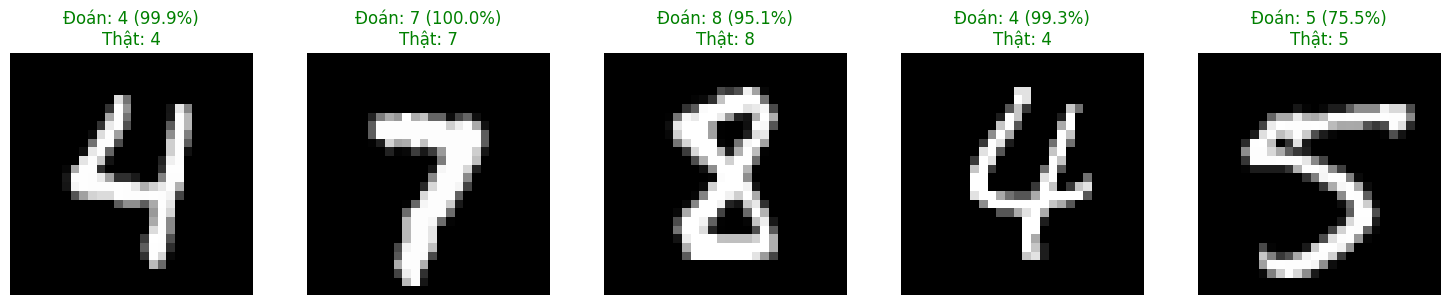

In [79]:
# CHƯƠNG TRÌNH KIỂM TRA KẾT QUẢ SAU HUẤN LUYỆN
def predict_and_show(model, x_test, y_test, num_samples=5):
    plt.figure(figsize=(15, 3))
    correct_count = 0

    # Thử nghiệm với các ảnh trong tập Test (Mạng chưa bao giờ nhìn thấy)
    for i in range(num_samples):
        idx = np.random.randint(0, len(x_test))
        img = x_test[idx]
        actual = y_test[idx]

        # Dự đoán
        probs = model.forward(img)
        prediction = np.argmax(probs)
        confidence = np.max(probs) * 100

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img.reshape(28, 28), cmap='gray')
        color = 'green' if prediction == actual else 'red'
        plt.title(f"Đoán: {prediction} ({confidence:.1f}%)\nThật: {actual}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Gọi hàm demo
predict_and_show(model, x_test, y_test)